[K-Nearest Neighbour](https://medium.com/swlh/k-nearest-neighbor-ca2593d7a3c4)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from mlxtend.plotting import plot_decision_regions

In [2]:
df = pd.read_csv("/content/BreastCancer.csv")

df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [3]:
df.drop(["id", "Unnamed: 32"], axis = 1, inplace = True)

In [4]:
df

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [5]:
from sklearn.model_selection import train_test_split

In [6]:
x_train, x_test, y_train, y_test = train_test_split(df.iloc[:, 1:], df.iloc[:, 0], test_size = 0.2, train_size = 0.8, random_state = 2)

In [7]:
from sklearn.preprocessing import StandardScaler

In [8]:
scaler = StandardScaler()

In [9]:
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [10]:
x_train.shape, x_test.shape

((455, 30), (114, 30))

In [11]:
from sklearn.neighbors import KNeighborsClassifier

In [12]:
knn = KNeighborsClassifier(n_neighbors = 3)

In [13]:
knn.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [14]:
from sklearn.metrics import accuracy_score

In [15]:
y_pred = knn.predict(x_test)

In [16]:
accuracy_score(y_test, y_pred)

0.9912280701754386

In [17]:
scores = []

for k in range(1, 21):
  knn = KNeighborsClassifier(n_neighbors = k)
  knn.fit(x_train, y_train)
  y_pred = knn.predict(x_test)
  scores.append(accuracy_score(y_test, y_pred))

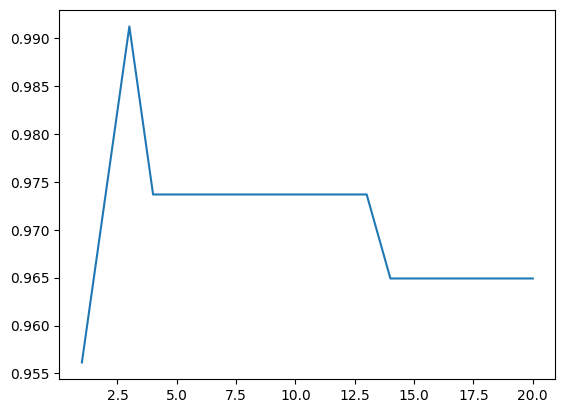

In [18]:
plt.plot(range(1, 21), scores)

In [19]:
df = pd.read_csv("/content/diabetes2.csv")

In [20]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [22]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [23]:
from sklearn.model_selection import train_test_split

In [24]:
x = df.drop("Outcome", axis = 1)
y = df["Outcome"]

In [25]:
x

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63
764,2,122,70,27,0,36.8,0.340,27
765,5,121,72,23,112,26.2,0.245,30
766,1,126,60,0,0,30.1,0.349,47


In [26]:
y

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64

In [27]:
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

Stratify parameter is used for stratified sampling based on the target variable y. It ensures that the proportion of classes in the target variable is preserved in both the training and testing sets. This is particularly useful for imbalanced datasets where one class is much more prevalent than the others. By using stratify=y, you ensure that the distribution of classes in both the training and testing sets is representative of the original dataset.

In [28]:
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state = 0, test_size = 0.3, stratify = y)

In [29]:
from sklearn.neighbors import KNeighborsClassifier

test_scores = []
train_scores = []

for i in range (1, 16):
  KNN = KNeighborsClassifier(i)
  KNN.fit(x_train, y_train)
  train_scores.append(KNN.score(x_train, y_train))
  test_scores.append(KNN.score(x_test, y_test))

In [30]:
max_train_score = max(train_scores)
train_scores_index = []

for i in range(len(train_scores)):
  if(train_scores[i]==max_train_score):
    train_scores_index.append(i+1)

print(f"Highest training score: {max_train_score * 100} %, with K = {train_scores_index}")

Highest training score: 100.0 %, with K = [1]


In [31]:
max_test_score = max(test_scores)
test_scores_index = []

for i in range(len(test_scores)):
  if(test_scores[i]==max_test_score):
    test_scores_index.append(i+1)

print(f"Highest test score: {max_test_score * 100} %, with K = {test_scores_index}")

Highest test score: 77.05627705627705 %, with K = [8]


In [32]:
print(len(train_scores))
print(len(test_scores))

15
15


<Axes: >

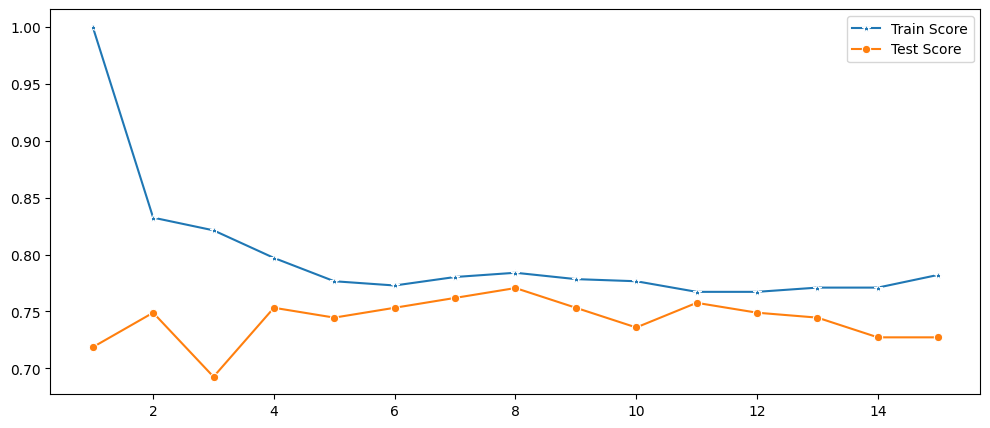

In [33]:
plt.figure(figsize = (12, 5))
sns.lineplot(x = range(1, 16), y = train_scores, marker = "*", label = "Train Score")
sns.lineplot(x = range(1, 16), y = test_scores, marker = "o", label = "Test Score")

In [34]:
KNN = KNeighborsClassifier(11)
KNN.fit(x_train, y_train)
KNN.score(x_test, y_test)

0.7575757575757576

Imagine you have a dataset with 8 features (let's call them Feature 0 through Feature 7). You want to visualize the decision boundaries of a k-Nearest Neighbors (k-NN) classifier. However, since you can only plot in two dimensions, you have to decide how to handle the other six features that are not being plotted.
The Plotting Challenge
When you plot decision boundaries in two dimensions (say Feature 0 on the x-axis and Feature 1 on the y-axis), you need to decide what to do with the other features (Feature 2 through Feature 7). If you ignore them, the plot won't be accurate. That's where filler_feature_values and filler_feature_ranges come in.

filler_feature_values
Purpose: To fix the values of the features that are not being plotted.
How it works: This is a dictionary where the key is the index of the feature, and the value is the constant value you want to use for that feature.
Example: {2: 20000, 3: 20000, 4: 20000, 5: 20000, 6: 20000, 7: 20000} means that Features 2 to 7 will each be fixed at the value 20000 when plotting the decision boundaries for Features 0 and 1.
filler_feature_ranges
Purpose: To specify the range of values around the fixed value for the unplotted features.
How it works: This is also a dictionary where the key is the index of the feature, and the value is the range width.
Example: {2: 20000, 3: 20000, 4: 20000, 5: 20000, 6: 20000, 7: 20000} means that while the values of Features 2 to 7 are fixed at 20000, they are allowed to vary within a range of 20000.

How They Work Together
When you use plot_decision_regions, you are essentially creating a 2D plot of the decision boundaries while considering that the other features (not plotted) are fixed or have some controlled variation. Here’s how this combination works:
Fixing Unplotted Features:
filler_feature_values={2: 20000, 3: 20000, 4: 20000, 5: 20000, 6: 20000, 7: 20000}: This fixes Features 2 to 7 at 20000. So, when you are plotting Features 0 and 1, the classifier is evaluated as if Features 2 to 7 have the value 20000.
Allowing Variation:
filler_feature_ranges={2: 20000, 3: 20000, 4: 20000, 5: 20000, 6: 20000, 7: 20000}: This allows Features 2 to 7 to vary within a range of 20000. This means that while Features 2 to 7 are centered at 20000, they can slightly vary, allowing the plot to better reflect potential variations in these features.

In [35]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from mlxtend.plotting import plot_decision_regions

In [36]:
# Load the diabetes dataset
diabetes = load_diabetes()
x = diabetes.data
y = (diabetes.target > np.median(diabetes.target)).astype(int)  # Binary classification: high vs. low diabetes progression

In [37]:
# Split the dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

# Standardize the features
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [38]:
scores = []

for i in range(1, 16):
  knn = KNeighborsClassifier(n_neighbors = i)
  knn.fit(x_train, y_train)
  y_pred = knn.predict(x_test)

  scores.append(accuracy_score(y_test, y_pred))

max_index = np.argmax(scores)
k = max_index + 1

In [39]:
print(f"Best Value of K is {k}")
print(scores)

Best Value of K is 14
[0.6766917293233082, 0.6917293233082706, 0.6842105263157895, 0.706766917293233, 0.706766917293233, 0.7218045112781954, 0.6917293233082706, 0.6992481203007519, 0.7293233082706767, 0.7293233082706767, 0.7443609022556391, 0.7443609022556391, 0.7819548872180451, 0.7894736842105263, 0.7894736842105263]


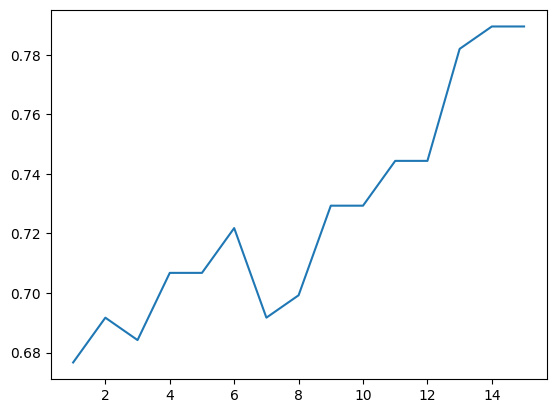

In [40]:
plt.plot(range(1, 16), scores)

In [41]:
knn = KNeighborsClassifier(n_neighbors = 14)
knn.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=14)

In [42]:
# Set the filler feature values and ranges
value = 0
width = 0

filler_feature_values = {i: value for i in range(2, x_train.shape[1])}
filler_feature_ranges = {i: width for i in range(2, x_train.shape[1])}

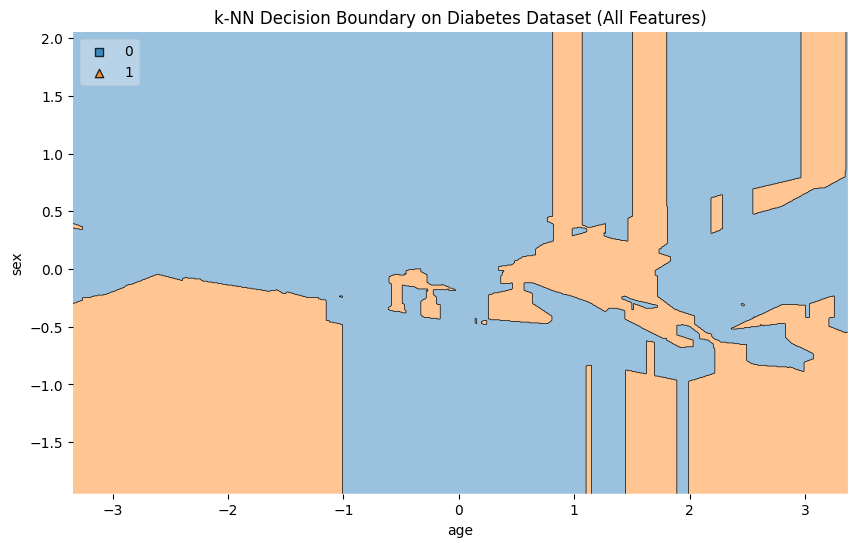

In [43]:
# Plot decision regions for the training data considering all features
plt.figure(figsize=(10, 6))
plot_decision_regions(x_train, y_train, clf=knn, legend=2,
                      filler_feature_values=filler_feature_values,
                      filler_feature_ranges=filler_feature_ranges,
                      X_highlight=x_test)


# Adding axes annotations and title
plt.xlabel(diabetes.feature_names[0])
plt.ylabel(diabetes.feature_names[1])
plt.title('k-NN Decision Boundary on Diabetes Dataset (All Features)')
plt.show()

filler_feature_values: Fixes non-plotted features to a specific value.

filler_feature_ranges: Allows for some controlled variation around the fixed value (usually set to zero for simplicity).

In [44]:
df = pd.read_csv("/content/iris.csv")

In [45]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [47]:
df.drop_duplicates(inplace=True)

In [48]:
df.shape

(147, 5)

In [49]:
X = df.drop("species", axis=1)

In [50]:
y = df["species"]

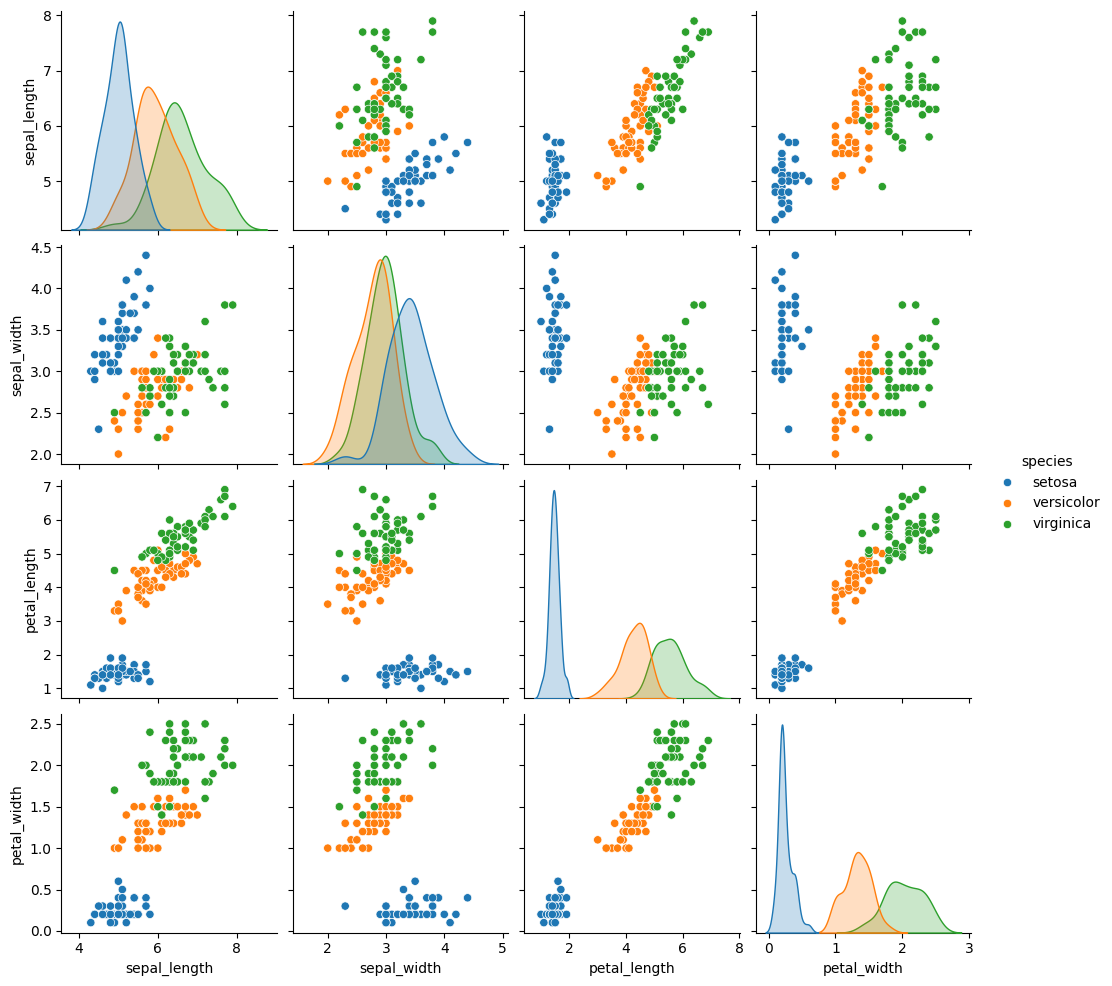

In [51]:
sns.pairplot(data=df, hue="species")

In [52]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [53]:
y = encoder.fit_transform(y)

In [54]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [56]:
scores = list()
for i in range(1, 16):
    KNN = KNeighborsClassifier(n_neighbors = i)
    KNN.fit(X_train, y_train)
    y_pred = KNN.predict(X_test)
    scores.append(accuracy_score(y_pred, y_test))
max_index = np.argmax(scores)
k = max_index+1
k

6

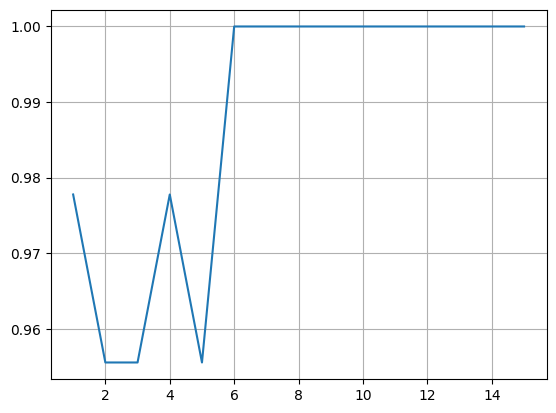

In [57]:
plt.plot(range(1,16), scores)
plt.grid()

In [58]:
KNN = KNeighborsClassifier(n_neighbors=k)
KNN.fit(X_train, y_train)
y_pred = KNN.predict(X_test)
print(accuracy_score(y_pred, y_test))

1.0


In [59]:
KNN

KNeighborsClassifier(n_neighbors=6)

In [60]:
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [61]:
feature_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

In [62]:
import plotly.express as px

fig = px.scatter_3d(df, x = feature_names[0], y = feature_names[1], z = feature_names[2], color = "species",
             labels = {feature_names[0]:feature_names[0], feature_names[1]:feature_names[1], feature_names[2]:feature_names[2]})
fig.show()

In [63]:
fig = px.scatter_3d(df, x = feature_names[0], y = feature_names[2], z = feature_names[3], color = "species",
             labels = {feature_names[0]:feature_names[0], feature_names[2]:feature_names[2], feature_names[3]:feature_names[3]})
fig.show()

In [64]:
fig = px.scatter_3d(df, x = feature_names[1], y = feature_names[2], z = feature_names[3], color = "species",
             labels = {feature_names[1]:feature_names[1], feature_names[2]:feature_names[2], feature_names[3]:feature_names[3]})
fig.show()

In [65]:
fig = px.scatter_3d(df, x = feature_names[0], y = feature_names[1], z = feature_names[3], color = "species",
             labels = {feature_names[0]:feature_names[0], feature_names[1]:feature_names[1], feature_names[3]:feature_names[3]})
fig.show()

In [66]:
fig = px.scatter_3d(df, x = feature_names[0], y = feature_names[2], z = feature_names[3], color = "species",
             labels = {feature_names[0]:feature_names[0], feature_names[2]:feature_names[2], feature_names[3]:feature_names[3]})
fig.show()

Penguins and Mall Customers